In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [25]:
cov = np.array([[1,0.2],[0.2,1]]).T
a = np.zeros((100,2)) #100np.array([1,1])
print(np.array(cov@(a.T)).shape)
prod = np.sum(a * np.array(cov@(a.T)).T, axis=1)


(2, 100)


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

[[ 1.5625 -0.9375]
 [-0.9375  1.5625]]


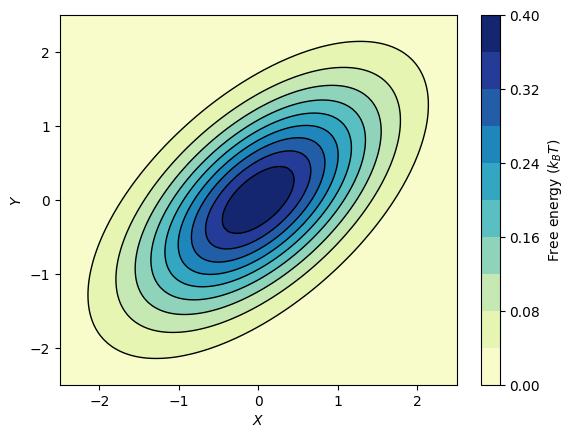

(100, 100) 769.4389162496439
(100, 100) 1.0


In [39]:
def target_prob(xdata, ydata):
    cov = np.array([[1,0.6],[0.6,1]])
    inv_cov = np.linalg.inv(cov)
    print(inv_cov)
    prod = xdata * xdata * inv_cov[0,0] + 2 * xdata * ydata * inv_cov[0,1] + ydata * ydata * inv_cov[1,1]

    return 1/np.sqrt(2*np.pi) * np.exp(-0.5*prod)

xdata, ydata = np.meshgrid(np.linspace(-2.5,2.5,100), np.linspace(-2.5,2.5,100), copy=True, sparse=False, indexing='xy')
prob = target_prob(xdata, ydata)

plt.contourf(xdata, ydata, prob, cmap='YlGnBu', levels=10)#, norm="log")
plt.colorbar(label='Free energy ($k_B T$)')
plt.contour(xdata, ydata, prob, colors='k', linewidths=1, levels=10)#, norm="log")
plt.xlabel("$X$")
plt.ylabel("$Y$")
plt.show()

print(prob.shape, prob.sum())
prob = prob / prob.sum()
print(prob.shape, prob.sum())

### Transfer Entropy

In [16]:
k = 7
taus = np.arange(5,505,5,dtype=int)
seeds = np.arange(1,21)

TEs_X_to_Y = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X = np.zeros((len(seeds),len(taus)))
TEs_X_to_Y_discrete = np.zeros((len(seeds),len(taus)))
TEs_Y_to_X_discrete = np.zeros((len(seeds),len(taus)))

for iseed, seed in enumerate(seeds):
    _, TEs_X_to_Y[iseed], TEs_Y_to_X[iseed] = (
        pickle.load(open(f"./pickles_te/seed{seed}_k{k}.p","rb"))
    )
avg_X_to_Y, err_X_to_Y = TEs_X_to_Y.mean(axis=0), TEs_X_to_Y.mean(axis=0) / np.sqrt(TEs_X_to_Y.shape[0])
avg_Y_to_X, err_Y_to_X = TEs_Y_to_X.mean(axis=0), TEs_Y_to_X.mean(axis=0) / np.sqrt(TEs_Y_to_X.shape[0])

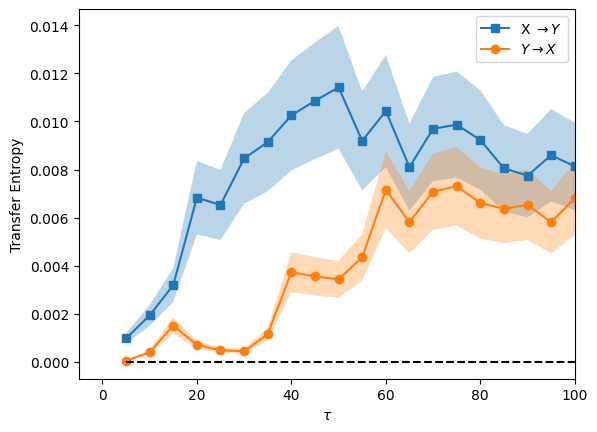

In [21]:
# NB labels exchanged because in trajectories X is faster than Y, but in simulations ref dipole angle (X)
# actually is slower than 1st shell dipole angle (Y)
plt.plot(taus, avg_Y_to_X, 's-', label="X $\\rightarrow Y$") # X: ref dipole, Y: 1st shell
plt.plot(taus, avg_X_to_Y, 'o-', label="$Y\\rightarrow X$")
plt.fill_between(taus, avg_Y_to_X-err_Y_to_X, avg_Y_to_X+err_Y_to_X, alpha=0.3)
plt.fill_between(taus, avg_X_to_Y-err_X_to_Y, avg_X_to_Y+err_X_to_Y, alpha=0.3)
plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("$\\tau$")
plt.ylabel("Transfer Entropy")
plt.xlim([-5, 100])
plt.legend()
plt.show()

### Imbalance Gain

In [46]:
def compute_IGs(imbalances, correction=True):    
    n_indep_realizations = imbalances.shape[0]
    n_taus = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_taus),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_taus),alphas_max] / np.sqrt(n_indep_realizations)

    if correction:
        IGs[imbalances[:,:,0].mean(axis=0) > 1] = 0
        errors[imbalances[:,:,0].mean(axis=0) > 1] = 0
        
    return IGs, errors

In [47]:
### Symmetric far wells along x, long time scales
k = 50
alphas = np.linspace(0,1,100)
taus = np.arange(5,505,5,dtype=int)
seeds = np.arange(1,21)

info_imbalances_X_to_Y = np.zeros((len(seeds),len(taus),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(seeds),len(taus),len(alphas)))

for iseed, seed in enumerate(seeds):
    _, info_imbalances_X_to_Y[iseed], info_imbalances_Y_to_X[iseed] = pickle.load( 
        open(f"./pickles_imb/seed{seed}_k{k}.p","rb")
    )

IGs_X_to_Y, errors_X_to_Y = compute_IGs(info_imbalances_X_to_Y, correction=False)
IGs_Y_to_X, errors_Y_to_X = compute_IGs(info_imbalances_Y_to_X, correction=False)

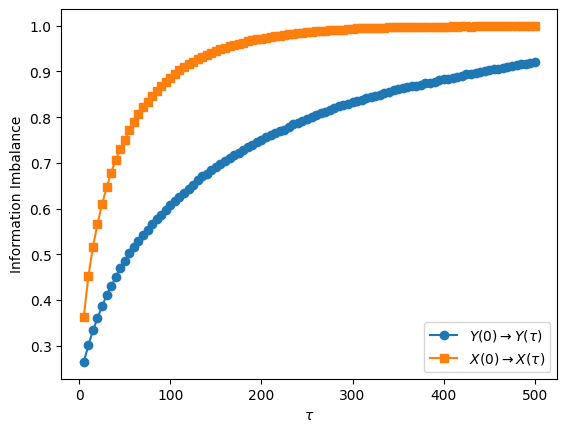

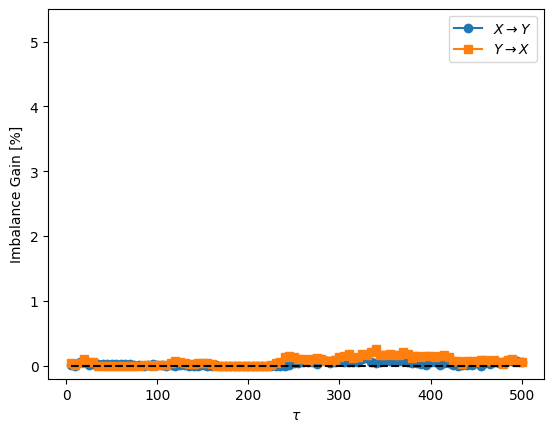

In [48]:
#Raw Information Imbalances:
plt.plot(taus, info_imbalances_X_to_Y.mean(axis=0)[:,0], 'o-', label="$Y(0)\\rightarrow Y(\\tau)$")
plt.plot(taus, info_imbalances_Y_to_X.mean(axis=0)[:,0], 's-', label="$X(0)\\rightarrow X(\\tau)$")
plt.xlabel("$\\tau$")
plt.ylabel("Information Imbalance")
plt.legend()
plt.show()

#Imbalance Gains:
plt.plot(taus, IGs_X_to_Y, 'o-', label="$X\\rightarrow Y$")
plt.plot(taus, IGs_Y_to_X, 's-', label="$Y\\rightarrow X$")
plt.fill_between(taus, IGs_X_to_Y-errors_X_to_Y, IGs_X_to_Y+errors_X_to_Y, alpha=0.3)
plt.fill_between(taus, IGs_Y_to_X-errors_Y_to_X, IGs_Y_to_X+errors_Y_to_X, alpha=0.3)
plt.hlines(0.0, taus[0], taus[-1], linestyle="--", color="black")
plt.xlabel("$\\tau$")
plt.ylabel("Imbalance Gain [%]")
plt.legend()
#plt.ylim([-0.2,5.5])
plt.show()

In [42]:
rho_x0xtau = 0.8
rho_x0y0 = 0.0
rho_y0ytau = 0.1
rho_x0ytau = 0.0

def diff_a(rho_x0xtau, rho_y0ytau):
    return 0.5 * np.log((1 - rho_y0ytau * rho_y0ytau) / (1 - rho_x0xtau * rho_x0xtau))

def diff_b(rho_x0y0, rho_x0xtau, rho_y0ytau, rho_x0ytau):
    arglog = ((1 + 2*rho_x0y0*rho_x0ytau*rho_y0ytau - 2*(rho_x0y0+rho_x0ytau+rho_y0ytau))
             /(1 + 2*rho_x0y0*rho_x0ytau*rho_x0xtau - 2*(rho_x0y0+rho_x0ytau+rho_x0xtau) ))
    print(arglog)
    return 0.5 * np.log(arglog)

print(diff_a(rho_x0xtau, rho_y0ytau),  diff_b(rho_x0y0, rho_x0xtau, rho_y0ytau, rho_x0ytau))

-1.3333333333333333
0.5058004558392402 nan


/tmp/ipykernel_6843/304794297.py:13: RuntimeWarning: invalid value encountered in log
  return 0.5 * np.log(arglog)
